In [1]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
result_dir = Path("results2")
metrics = [
  "board.processor.cores.core.iew.branchMispredicts",
  "board.processor.cores.core.cpi",
  ]

In [6]:
branches = []
robs = []

results = []

data_str = ""

for dir in result_dir.glob("*"):
  name = dir.name
  stat_file = dir / "stats.txt"

  branch = name.split("_")[1]
  if(branch not in branches):
    branches.append(branch)

  rob = int(name.split("_")[2].replace("rob",""))
  if(rob not in robs):
    robs.append(rob)
  
  index = [branches.index(branch), robs.index(rob)]
  print(index)
  
  with open(stat_file) as result_file:
   content = result_file.read()
   for metric in metrics:
    matcher = f"{metric}[ ]*([0-9].[0-9]*)" 

    metric_search = re.search(matcher, content, re.IGNORECASE)
    if metric_search:
        result = float(metric_search.group(1))
    
    results.append([index, metric, result])

    out_str = (f"Issue Width : {branch} | Reorder Buffer (ROB) Size:{rob} : | Metric: {metric.split(".")[-1]}:  {result}\n")
    data_str += out_str
    print(out_str) 

[0, 0]
Issue Width : branchLocalBP | Reorder Buffer (ROB) Size:32 : | Metric: branchMispredicts:  143624.0

Issue Width : branchLocalBP | Reorder Buffer (ROB) Size:32 : | Metric: cpi:  0.797432

[0, 1]
Issue Width : branchLocalBP | Reorder Buffer (ROB) Size:64 : | Metric: branchMispredicts:  143715.0

Issue Width : branchLocalBP | Reorder Buffer (ROB) Size:64 : | Metric: cpi:  0.782374

[1, 0]
Issue Width : branchMPPTAGE64KB | Reorder Buffer (ROB) Size:32 : | Metric: branchMispredicts:  3399.0

Issue Width : branchMPPTAGE64KB | Reorder Buffer (ROB) Size:32 : | Metric: cpi:  0.802327

[1, 1]
Issue Width : branchMPPTAGE64KB | Reorder Buffer (ROB) Size:64 : | Metric: branchMispredicts:  3471.0

Issue Width : branchMPPTAGE64KB | Reorder Buffer (ROB) Size:64 : | Metric: cpi:  0.802267



In [9]:
def get_heatmap_data_from_res(res):
  for metric in metrics:
    y_names = branches
    x_names = robs
    data = np.zeros([len(x_names), len(y_names)])
    for r in res:
      if(r[1] == metric):
        data[r[0][1], r[0][0]] = r[2]
    yield (x_names, y_names, data, metric)


In [11]:
heatm_folder = Path("heatmaps2")

In [12]:
def create_heatmap(x_names, y_names, data,metric):
  fig, ax = plt.subplots()
  im = ax.imshow(data)

  # Show all ticks and label them with the respective list entries
  ax.set_xticks(range(len(y_names)), labels=y_names,
                rotation=45, ha="right", rotation_mode="anchor")
  ax.set_yticks(range(len(x_names)), labels=x_names)

  # Loop over data dimensions and create text annotations.
  for i in range(len(x_names)):
      for j in range(len(y_names)):
          text = ax.text(j, i, data[i, j],
                        ha="center", va="center", color="w")

  ax.set_title(metric)
  ax.set_ylabel("ROB Size")
  ax.set_xlabel("Issue width")
  fig.tight_layout()
  fig.savefig(heatm_folder / f"{metric}.png")
  plt.show()
  return fig

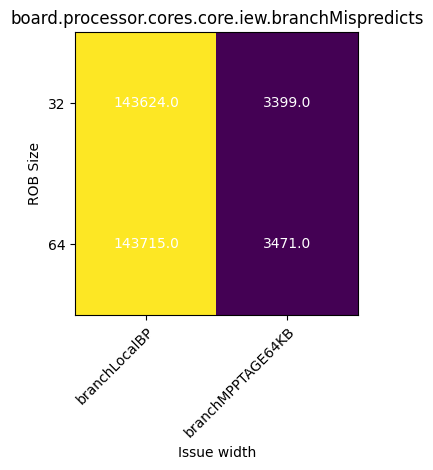

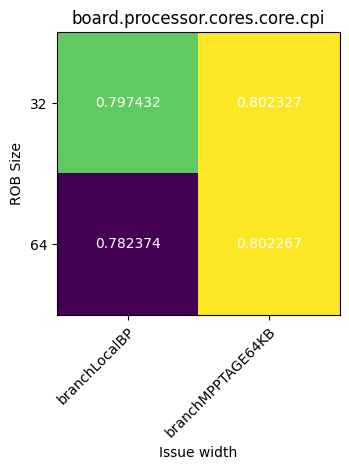

In [13]:
for out in get_heatmap_data_from_res(results):
  create_heatmap(*out)

In [8]:
from ollama import Client
client = Client(
  host='http://localhost:11434',
)

for model in client.list()["models"]:
  print(model["model"])

deepscaler:1.5b
gemma3:4b
qwen2.5-coder:1.5b


In [41]:
navodilo = open("navodilo.txt").read()
prompt = f"I'll give you the exercise and the data, generate a short report. Answer strictly just the questions from the task provided!: \n {navodilo} \n Here is the data: \n {data_str}"

In [42]:
out = client.generate("deepscaler:1.5b", prompt=prompt)

In [43]:

open("report.md", "w").write(out["response"].split("</think>")[-1])

2591

In [44]:
prompt

"I'll give you the exercise and the data, generate a short report. Answer strictly just the questions from the task provided!: \n In the first task, you will evaluate the performance of the O3 processor model that we developed during the lab exercises. To carry out this assessment, you will use the Whetstone benchmark, which can be found in the workload/Whetstone/ folder.\n\nWhetstone benchmark\nThe Whetstone benchmark is an one of the method used to evaluate CPU performance, particularly for scientific applications. It consists of several modules that represent a range of operations commonly performed in scientific programs. The benchmark utilizes a variety of C functions, including sin, cos, sqrt, exp, and log, along with integer and floating-point mathematical operations, array accesses, conditional branches, and procedure calls.\n\nObjectives\n\nEvaluate the performance of the out-of-order (OoO) processor by running the Whetstone benchmark in GEM5. Modify the following parameters o

In [14]:
data_str

'Issue Width : branchLocalBP | Reorder Buffer (ROB) Size:32 : | Metric: branchMispredicts:  143624.0\nIssue Width : branchLocalBP | Reorder Buffer (ROB) Size:32 : | Metric: cpi:  0.797432\nIssue Width : branchLocalBP | Reorder Buffer (ROB) Size:64 : | Metric: branchMispredicts:  143715.0\nIssue Width : branchLocalBP | Reorder Buffer (ROB) Size:64 : | Metric: cpi:  0.782374\nIssue Width : branchMPPTAGE64KB | Reorder Buffer (ROB) Size:32 : | Metric: branchMispredicts:  3399.0\nIssue Width : branchMPPTAGE64KB | Reorder Buffer (ROB) Size:32 : | Metric: cpi:  0.802327\nIssue Width : branchMPPTAGE64KB | Reorder Buffer (ROB) Size:64 : | Metric: branchMispredicts:  3471.0\nIssue Width : branchMPPTAGE64KB | Reorder Buffer (ROB) Size:64 : | Metric: cpi:  0.802267\n'